---
title: "Implementing Fast Pauli Decomposition with the Walsh-Hadamard Transform"
author: "Philipp Greiner, Adapted by Adelina Bärligea"
date: "2026-08-21"
categories: [code]
image: "preview.png"
image-width: "1cm"
image-height: "1cm"
format:
  html:
    code-fold: false
    toc: true
    cap-location: bottom
jupyter: blogqa
execute:
  enabled: false
---

Pauli decompositions express quantum operators in a standard basis that is convenient for simulation, measurement, and algorithm design. This tutorial shows how all Pauli coefficients can be computed efficiently using an XOR permutation and the fast Walsh–Hadamard transform, avoiding the repeated work of calculating every coefficient separately.

An arbitrary $n$-qubit matrix $A\in\mathbb C^{2^n\times 2^n}$ can be written as

$$
A=\sum_{P\in\{I,X,Y,Z\}^{\otimes n}}\alpha_P P.
$$

The direct formula for each coefficient is straightforward, but evaluating it independently for all $4^n$ Pauli strings is computationally repetitive. In the following, we implement and explain the faster construction proposed by [Georges *et al.*](https://doi.org/10.1088/1367-2630/adb44d), in which after an XOR permutation, all coefficients are obtained with row-wise fast Walsh-Hadamard transforms (FWHTs). For an $N\times N$ matrix with $N=2^n$, the coefficient transform costs $\mathcal O(N^2\log N)$ operations in this method. Most of the code presented here is based on this [GitHub repository](https://github.com/riverlane/pauli_lcu) by Riverlane.


## The Pauli basis

The $4^n$ Pauli strings form an orthonormal operator basis under the normalized Hilbert-Schmidt inner product. Consequently,

$$
\alpha_P=\frac{1}{2^n}\operatorname{tr}(P^\dagger A).
$$

We begin with the one-qubit matrices and a helper that constructs a tensor-product Pauli string. These helpers will also let us verify the fast algorithm independently.


In [1]:
import math
from functools import reduce
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PAULI = {
    "I": np.eye(2, dtype=complex),
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.diag([1, -1]).astype(complex),
}

def pauli_matrix(label):
    """Return the matrix represented by a label such as 'IXY'."""
    return reduce(np.kron, (PAULI[symbol] for symbol in label))

As a first example, consider the two-qubit string $X\otimes Y$. Its decomposition should contain exactly one nonzero coefficient: $\alpha_{XY}=1$.


In [2]:
matrix_xy = pauli_matrix("XY")
matrix_xy

array([[0.+0.j, 0.-0.j, 0.+0.j, 0.-1.j],
       [0.+0.j, 0.+0.j, 0.+1.j, 0.+0.j],
       [0.+0.j, 0.-1.j, 0.+0.j, 0.-0.j],
       [0.+1.j, 0.+0.j, 0.+0.j, 0.+0.j]])

## From traces to one fast transform

Index the Pauli strings by two $n$-bit integers $r$ and $s$:

$$
P_{r,s}=\bigotimes_{j=0}^{n-1} i^{r_j s_j}X^{r_j}Z^{s_j}.
$$

For each qubit, the pair $(r_j,s_j)$ selects $I,X,Z,$ or $Y$, respectively. The coefficient formula derived by Georges *et al.* is

$$
\alpha_{r,s}
=\frac{(-i)^{|r\wedge s|}}{2^n}
\sum_{q=0}^{2^n-1} A_{r\oplus q,q}
\left(H^{\otimes n}\right)_{q,s},
$$

where $\oplus$ and $\wedge$ denote bitwise XOR and AND, $|\cdot|$ is the Hamming weight, and $H$ is the unnormalized Hadamard matrix. The formula suggests three computational steps.


### 1. XOR permutation

First rearrange the matrix entries according to

$$
B_{r,q}=A_{r\oplus q,q}.
$$

The permutation groups together all entries that contribute to Pauli strings with the same $X/Y$ support $r$.


In [3]:
xor_xy = matrix_xy.copy()
dim = xor_xy.shape[0]

b = 0
for j in range(dim):
    a = 0
    for i in range(j):
        temp = xor_xy[b, i ^ j]
        xor_xy[b, i ^ j] = xor_xy[a, i ^ j]
        xor_xy[a, i ^ j] = temp
        a += 1
    b += 1

xor_xy

array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.-0.j, 0.+0.j, 0.-0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+1.j, 0.-1.j, 0.+1.j, 0.-1.j]])

### 2. Fast Walsh-Hadamard transform, phases, and normalization

Every row of $B$ is multiplied by $H^{\otimes n}$. Philipp's implementation performs this multiplication with explicit butterfly operations, so the full $N\times N$ Hadamard matrix is never constructed. After transforming a row, the same loop applies the phase $(-i)^{|r\wedge s|}$ and divides by $N=2^n$. Keeping these operations together mirrors the implementation developed in the project.


In [4]:
transformed_xy = xor_xy.copy()

for j in range(dim):
    # Walsh-Hadamard transform of row j
    hf = 1
    while hf < dim:
        b = j * dim
        while b < j * dim + dim:
            a = b
            b += hf
            for i in range(hf):
                temp = transformed_xy[b // dim, b % dim]
                transformed_xy[b // dim, b % dim] = (
                    transformed_xy[a // dim, a % dim] - temp
                )
                transformed_xy[a // dim, a % dim] += temp
                b += 1
                a += 1
        hf *= 2

    # Phase correction and normalization of row j
    d = 0
    for i in range(dim):
        match (i & j).bit_count() & 0b11:
            case 1:
                transformed_xy[j, d] *= -1j
            case 2:
                transformed_xy[j, d] *= -1
            case 3:
                transformed_xy[j, d] *= 1j
        transformed_xy[j, d] /= dim
        d += 1

np.round(transformed_xy, 12)

array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.-0.j, 0.+0.j, 0.-0.j],
       [0.+0.j, 0.+0.j, 0.-0.j, 0.-0.j],
       [0.+0.j, 1.-0.j, 0.-0.j, 0.+0.j]])

### 3. Mapping coefficient indices to Pauli strings

After the transform, each matrix position corresponds to one Pauli string. For two qubits, the layout is shown below. Constructing this complete string-valued matrix would itself require $4^n$ strings, so the project implementation generates labels only for nonzero coefficients. It does this by interleaving the bits of the two matrix indices.


In [5]:
pauli_layout_2q = np.array(
    [
        ["II", "IZ", "ZI", "ZZ"],
        ["IX", "IY", "ZX", "ZY"],
        ["XI", "XZ", "YI", "YZ"],
        ["XX", "XY", "YX", "YY"],
    ]
)
pauli_layout_2q

array([['II', 'IZ', 'ZI', 'ZZ'],
       ['IX', 'IY', 'ZX', 'ZY'],
       ['XI', 'XZ', 'YI', 'YZ'],
       ['XX', 'XY', 'YX', 'YY']], dtype='<U2')

## Complete implementation

In the complete implementation below, the coefficient transform works in-place and deliberately keeps the XOR permutation, FWHT, phase correction, and normalization in one routine. The public wrapper first validates and copies the input matrix, then converts only numerically nonzero entries into Pauli labels with the bit-interleaving routine.

In [6]:
#| code-fold: true
#| code-summary: "Show full implementation"
def pauli_coefficients(data):
    """Transform a square 2^n by 2^n matrix into Pauli coefficients in-place."""
    dim = data.shape[0]

    # XOR transform
    b = 0
    for j in range(dim):
        a = 0
        for i in range(j):
            temp = data[b, i ^ j]
            data[b, i ^ j] = data[a, i ^ j]
            data[a, i ^ j] = temp
            a += 1
        b += 1

    for j in range(dim):
        # Walsh-Hadamard transform
        hf = 1
        while hf < dim:
            b = j * dim
            while b < j * dim + dim:
                a = b
                b += hf
                for i in range(hf):
                    temp = data[b // dim, b % dim]
                    data[b // dim, b % dim] = data[a // dim, a % dim] - temp
                    data[a // dim, a % dim] += temp
                    b += 1
                    a += 1
            hf *= 2

        # Phase correction and normalization
        d = 0
        for i in range(dim):
            match (i & j).bit_count() & 0b11:
                case 1:
                    data[j, d] *= -1j
                case 2:
                    data[j, d] *= -1
                case 3:
                    data[j, d] *= 1j
            data[j, d] /= dim
            d += 1


def interleave_with_zeroes(word):
    word = (word ^ (word << 16)) & 0x0000FFFF0000FFFF
    word = (word ^ (word << 8)) & 0x00FF00FF00FF00FF
    word = (word ^ (word << 4)) & 0x0F0F0F0F0F0F0F0F
    word = (word ^ (word << 2)) & 0x3333333333333333
    word = (word ^ (word << 1)) & 0x5555555555555555
    return word


def pauli_string_ij(i, j, num_qubits):
    identifier = interleave_with_zeroes(i ^ j) | (interleave_with_zeroes(j) << 1)
    paulis = []
    num_qubits -= 1
    while num_qubits >= 0:
        match identifier >> (2 * num_qubits) & 0b11:
            case 0:
                paulis.append("I")
            case 1:
                paulis.append("X")
            case 2:
                paulis.append("Y")
            case 3:
                paulis.append("Z")
        num_qubits -= 1
    return "".join(paulis)


def pauli_decomposition(matrix, atol=1e-12):
    """Return the numerically nonzero (coefficient, Pauli label) pairs."""
    data = np.asarray(matrix, dtype=complex)
    if data.ndim != 2 or data.shape[0] != data.shape[1]:
        raise ValueError("matrix must be square")

    dim = data.shape[0]
    if dim == 0 or dim & (dim - 1):
        raise ValueError("matrix dimension must be a power of two")

    data = data.copy()
    pauli_coefficients(data)
    num_qubits = int(math.log2(dim))

    pauli_strings = []
    for i in range(dim):
        for j in range(dim):
            if abs(data[i, j]) > atol:
                coefficient = np.real_if_close(data[i, j]).item()
                label = pauli_string_ij(i, j, num_qubits)
                pauli_strings.append((coefficient, label))
    return pauli_strings

pauli_decomposition(matrix_xy)

[(1.0, 'XY')]

## Verification by reconstruction

The $XY$ example checks the index and phase convention, but a dense random matrix is a stronger test because all Pauli coefficients are generally nonzero. We reconstruct such a matrix from the returned terms and compare it with the input.


In [7]:
def reconstruct(terms):
    dimension = pauli_matrix(terms[0][1]).shape[0]
    result = np.zeros((dimension, dimension), dtype=complex)
    for coefficient, label in terms:
        result += coefficient * pauli_matrix(label)
    return result

rng = np.random.default_rng(7)
test_matrix = rng.normal(size=(4, 4)) + 1j * rng.normal(size=(4, 4))
test_terms = pauli_decomposition(test_matrix)
reconstruction_error = np.linalg.norm(reconstruct(test_terms) - test_matrix)

print(f"number of returned terms: {len(test_terms)}")
print(f"reconstruction error: {reconstruction_error:.3e}")
assert reconstruction_error < 1e-12

number of returned terms: 16
reconstruction error: 4.536e-16


## Computational cost

For $N=2^n$, the XOR permutation touches $N^2$ entries and the row-wise FWHT uses $N$ transforms of length $N$. The coefficient calculation therefore scales as

$$
\mathcal O(N^2\log N)=\mathcal O(n4^n).
$$

This is a substantial improvement over evaluating all trace formulas independently, but it is still exponential in the qubit count. That is unavoidable for a general dense decomposition, as the output itself contains $4^n=N^2$ coefficients.


## Runtime experiment

The following compact experiment benchmarks the in-place `pauli_coefficients` transform, excluding random-matrix generation, the protective input copy, and conversion to Pauli labels. For each system size, one fixed random complex matrix is transformed in 12 repetitions after a warm-up run. The median and interquartile range summarize the variability of runtimes. The dashed curve is the predicted $n4^n$ scaling normalized to the measured value at $n=7$.

Note that these timings only reflect this NumPy implementation on one machine, so they should not be treated as a hardware-independent performance claim.

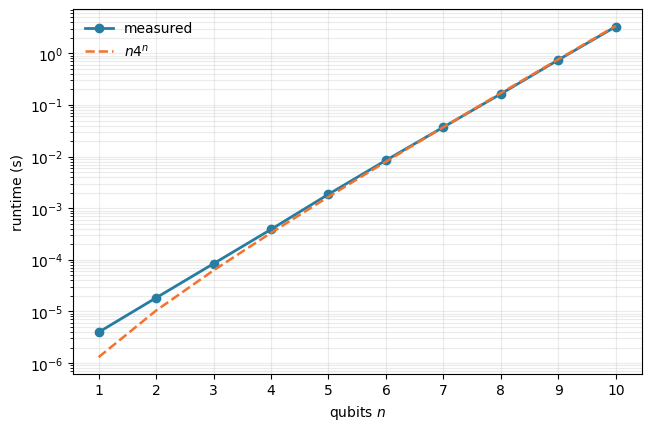

In [8]:
#| code-fold: true
#| code-summary: "Show benchmark code"

def benchmark_transform(max_qubits=10, repetitions=12):
    records = []
    for n_qubits in range(1, max_qubits + 1):
        dimension = 2**n_qubits
        rng = np.random.default_rng(1000 + n_qubits)
        matrix = rng.normal(size=(dimension, dimension))
        matrix = matrix + 1j * rng.normal(size=(dimension, dimension))

        pauli_coefficients(matrix.copy())  # warm-up
        for repetition in range(repetitions):
            working_matrix = matrix.copy()
            start = perf_counter()
            pauli_coefficients(working_matrix)
            elapsed = perf_counter() - start
            records.append((n_qubits, repetition, elapsed))

    return pd.DataFrame(records, columns=["n_qubits", "repetition", "runtime_seconds"])


data_path = Path("runtime_data.csv")
REGENERATE = False
if data_path.exists() and not REGENERATE:
    timing_data = pd.read_csv(data_path)
else:
    timing_data = benchmark_transform()
    timing_data.to_csv(data_path, index=False)

summary = timing_data.groupby("n_qubits")["runtime_seconds"].agg(
    median="median",
    q25=lambda values: values.quantile(0.25),
    q75=lambda values: values.quantile(0.75),
)

n_values = summary.index.to_numpy()
guide = n_values * 4.0**n_values
anchor = 7
guide *= summary.loc[anchor, "median"] / (anchor * 4.0**anchor)

fig, ax = plt.subplots(figsize=(6.4, 4.2), constrained_layout=True)
ax.plot(n_values, summary["median"], "o-", color="#277DA1", lw=2, label="measured")
ax.fill_between(
    n_values,
    summary["q25"].to_numpy(),
    summary["q75"].to_numpy(),
    color="#43AA8B",
    alpha=0.22,
    linewidth=0,
)
ax.plot(n_values, guide, "--", color="#F3722C", lw=1.8, label=r"$n4^n$")
ax.set_yscale("log")
ax.set_xlabel("qubits $n$")
ax.set_ylabel("runtime (s)")
ax.set_xticks(n_values)
ax.grid(alpha=0.25, which="both")
ax.legend(frameon=False)
fig.savefig("runtime.png", dpi=220)
plt.show()


Notice that the measured curve follows the expected exponential trend once the matrices are large enough for transform work to dominate Python and timer overhead. At small sizes, absolute runtimes are so short that fixed overhead and system noise obscure the asymptotic behavior.


## References

- T. N. Georges, B. K. Berntson, C. Suenderhauf, and A. V. Ivanov, [*Pauli decomposition via the fast Walsh-Hadamard transform*](https://doi.org/10.1088/1367-2630/adb44d), New Journal of Physics **27**, 033004 (2025). [arXiv:2408.06206](https://arxiv.org/abs/2408.06206).
